### Concepts Covered

**ResidualBlock**:	Custom residual connection layer with skip connections

**build_residual_model**():	Keras Model subclass using custom residual blocks

**MyMomentumOptimizer**:	Custom optimizer mimicking SGD with momentum

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load Data

In [29]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train[..., np.newaxis] / 255.0
X_test = X_test[..., np.newaxis] / 255.0

# Residual Block

In [30]:
# 🔁 Residual Block
class ResidualBlock(layers.Layer):
    def __init__(self, filters, kernel_size, **kwargs):
        super().__init__(**kwargs)
        self.conv1 = layers.Conv2D(filters, kernel_size, padding="same", activation="relu")
        self.conv2 = layers.Conv2D(filters, kernel_size, padding="same")

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.conv2(x)
        return tf.nn.relu(x + inputs)

# Build model

In [31]:
# Build model
def build_model():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = ResidualBlock(32, 3)(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(10)(x)
    return keras.Model(inputs, outputs)

# Initialize model

In [32]:
# Initialize model
model = build_model()
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
learning_rate = 0.01
momentum = 0.9
trainable_vars = model.trainable_variables
velocities = [tf.Variable(tf.zeros_like(var), trainable=False) for var in trainable_vars]

# Metrics and logs

In [33]:
# Metrics and logs
train_acc = keras.metrics.SparseCategoricalAccuracy()
val_acc = keras.metrics.SparseCategoricalAccuracy()
train_loss_log, val_loss_log = [], []
train_acc_log, val_acc_log = [], []

epochs = 5
batch_size = 64
steps_per_epoch = len(X_train) // batch_size

# Training Loop

In [34]:
# 🔁 Training Loop
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    idx = np.random.permutation(len(X_train))
    X_shuffled = X_train[idx]
    y_shuffled = y_train[idx]

    train_acc.reset_state()
    train_loss_epoch = []

    for step in range(steps_per_epoch):
        x_batch = X_shuffled[step * batch_size:(step + 1) * batch_size]
        y_batch = y_shuffled[step * batch_size:(step + 1) * batch_size]

        with tf.GradientTape() as tape:
            logits = model(x_batch, training=True)
            loss = loss_fn(y_batch, logits)

        grads = tape.gradient(loss, trainable_vars)

        # Manual momentum update
        for v, g, vel in zip(trainable_vars, grads, velocities):
            vel.assign(momentum * vel - learning_rate * g)
            v.assign_add(vel)

        train_acc.update_state(y_batch, logits)
        train_loss_epoch.append(loss.numpy())

    train_loss_log.append(np.mean(train_loss_epoch))
    train_acc_log.append(train_acc.result().numpy())

    # Validation
    val_acc.reset_state()
    val_logits = model(X_test, training=False)
    val_loss = loss_fn(y_test, val_logits).numpy()
    val_loss_log.append(val_loss)
    val_acc.update_state(y_test, val_logits)
    val_acc_log.append(val_acc.result().numpy())

    print(f"Train Loss: {train_loss_log[-1]:.4f} | Train Acc: {train_acc_log[-1]:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc_log[-1]:.4f}")



Epoch 1/5
Train Loss: 0.4935 | Train Acc: 0.8241 | Val Loss: 0.3647 | Val Acc: 0.8702

Epoch 2/5
Train Loss: 0.3020 | Train Acc: 0.8910 | Val Loss: 0.2991 | Val Acc: 0.8880

Epoch 3/5
Train Loss: 0.2480 | Train Acc: 0.9087 | Val Loss: 0.2666 | Val Acc: 0.9001

Epoch 4/5
Train Loss: 0.2127 | Train Acc: 0.9228 | Val Loss: 0.2588 | Val Acc: 0.9082

Epoch 5/5
Train Loss: 0.1843 | Train Acc: 0.9317 | Val Loss: 0.2361 | Val Acc: 0.9126


# Plot results

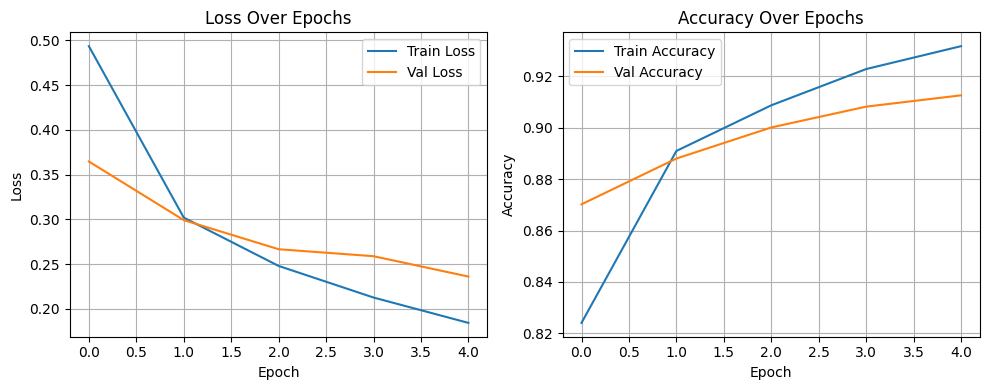

In [35]:
# 📊 Plot results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_loss_log, label="Train Loss")
plt.plot(val_loss_log, label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_acc_log, label="Train Accuracy")
plt.plot(val_acc_log, label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()